Detected ICD chapter column: None

=== Baseline program ===
Baseline MDE (α=0.05, 80.0% power): 3.183%


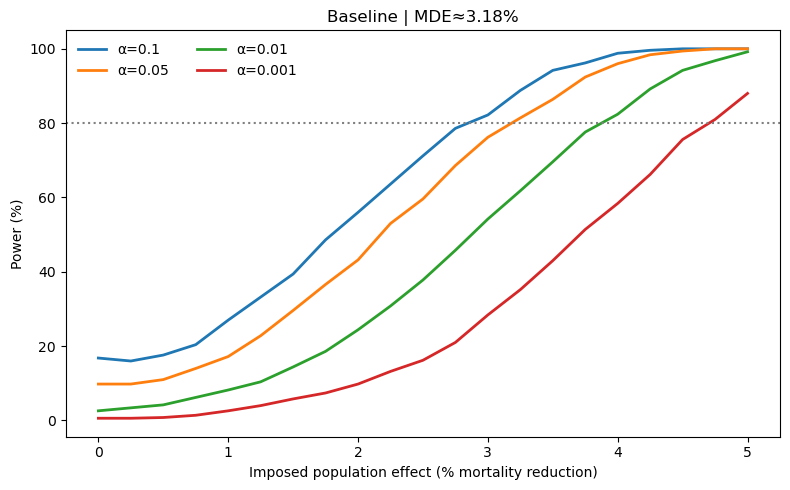


=== LLM proposing adjacent programs (same dataset) ===
Wrote adjacent_programs.json

=== Running program: earlier_last_year ===
Rationale: Shift last_year earlier to 2008 reduces post period length and total data, likely increasing MDE due to less post-treatment data.
LM expected MDE direction: increase
Filter: None


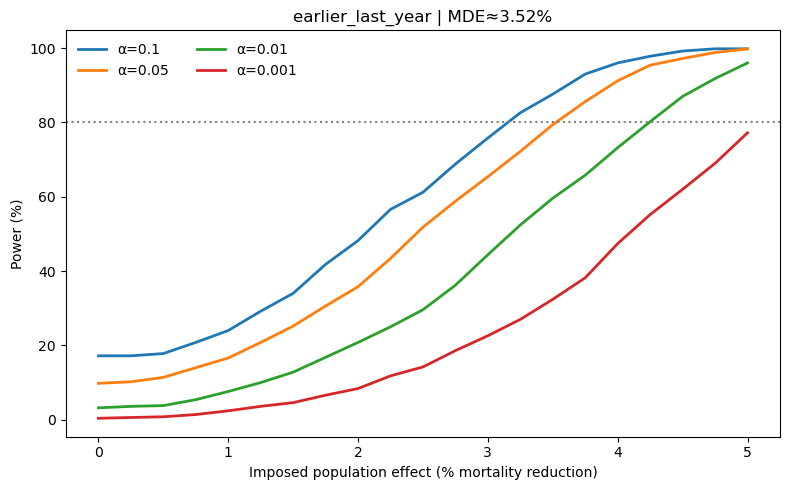


=== Running program: longer_pre_period ===
Rationale: Increasing pre_years to 8 improves baseline trend estimation, which may reduce MDE by improving power.
LM expected MDE direction: decrease
Filter: None


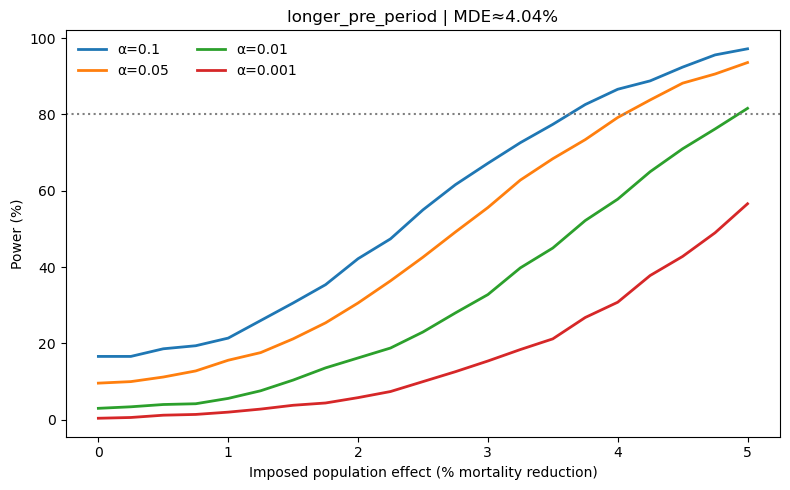


=== Running program: more_treated_states ===
Rationale: Increasing n_treated to 35 increases sample size of treated units, likely decreasing MDE by improving power.
LM expected MDE direction: decrease
Filter: None


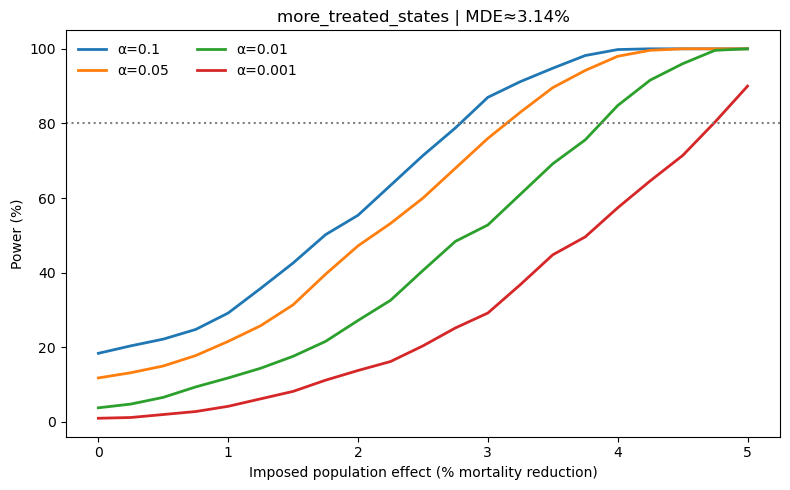


=== Running program: longer_post_period ===
Rationale: Increasing post_years to 6 provides more post-treatment data, improving power and reducing MDE.
LM expected MDE direction: decrease
Filter: None


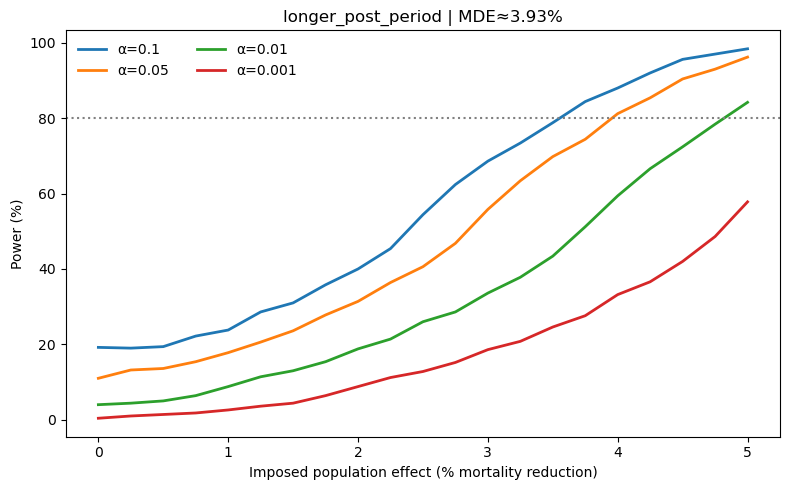


=== Running program: restrict_to_later_years ===
Rationale: Filtering to years >= 2005 reduces total sample size and pre period length, likely increasing MDE.
LM expected MDE direction: increase
Filter: year >= 2005


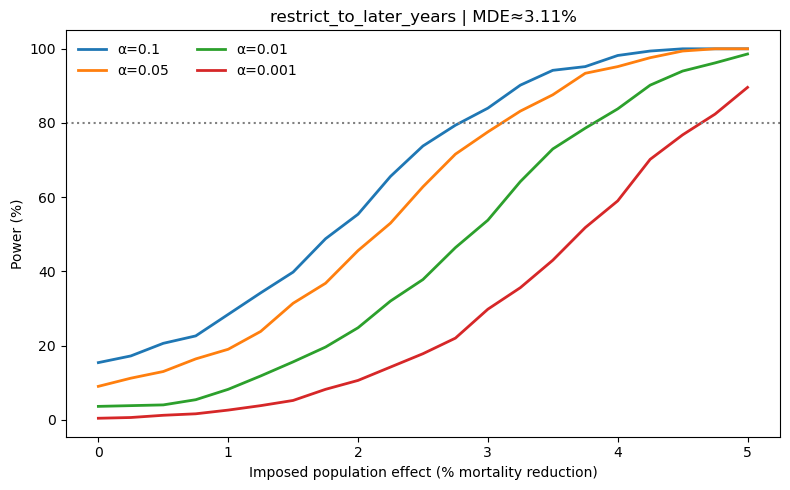


=== Running program: combined_less_treated_and_earlier_last_year ===
Rationale: Reducing n_treated to 10 and last_year to 2008 reduces treated sample and post period, likely increasing MDE substantially.
LM expected MDE direction: increase
Filter: None


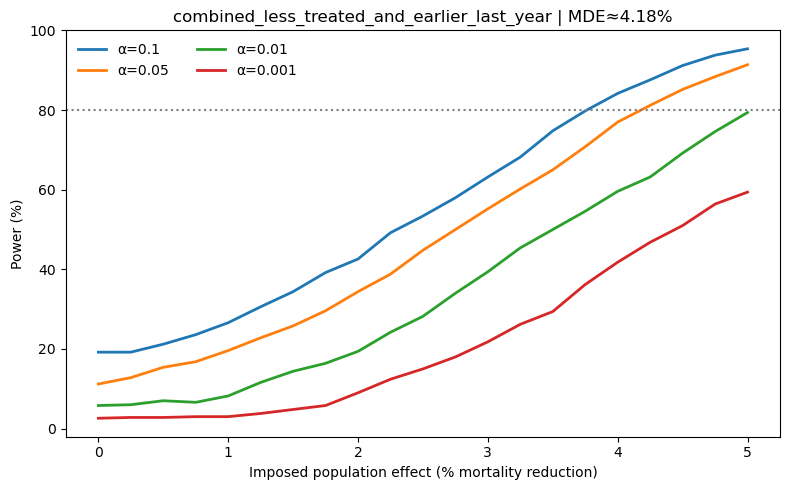


Wrote adjacent_program_results.csv
                                    program_id   mde_pct  \
4                      restrict_to_later_years  3.107143   
2                          more_treated_states  3.142857   
0                            earlier_last_year  3.524194   
3                           longer_post_period  3.928571   
1                            longer_pre_period  4.043478   
5  combined_less_treated_and_earlier_last_year  4.178571   

  lm_expected_direction realized_direction_vs_baseline  last_year  pre_years  \
4              increase                       decrease       2011          5   
2              decrease                       decrease       2011          5   
0              increase                       increase       2008          5   
3              decrease                       increase       2011          5   
1              decrease                       increase       2011          8   
5              increase                       increase       20

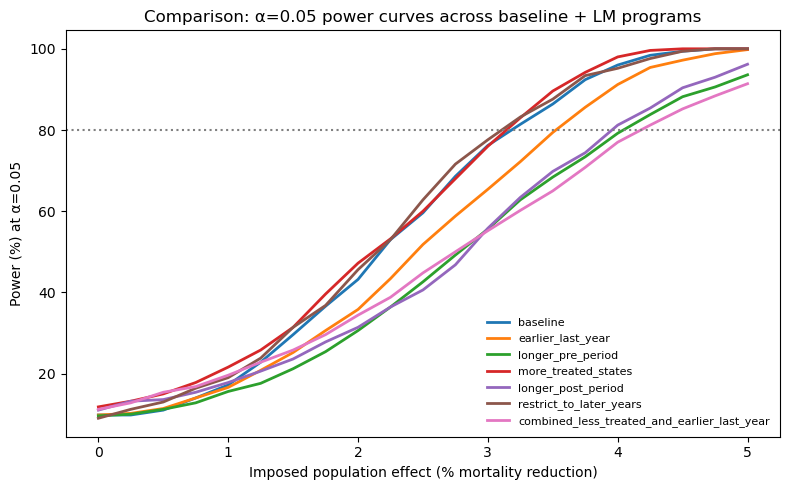

In [1]:
from __future__ import annotations

import os, json
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import t

from dotenv import load_dotenv
from openai import OpenAI
from pydantic import BaseModel, Field


# =============================================================================
# SETTINGS
# =============================================================================

BASELINE_PATH = Path("Multiple Cause of Death, 1999-2020.csv")

ALPHAS = [0.10, 0.05, 0.01, 0.001]
TARGET_POWER = 80.0
ALPHA_FOR_MDE = 0.05
RNG_SEED = 1234

# FIXED simulation settings (do not let LM change these; makes results comparable)
SIM_FIXED = dict(
    n_sim=500,
    effect_grid_step=0.0025,
    effect_grid_end=0.05,
)

# Baseline program (only filter + design window knobs)
BASELINE_PROGRAM = dict(
    program_id="baseline",
    rationale="Baseline: no filtering; collapse to state×year; log(rate+1); pseudo post=2011; 5 pre / 3 post; n_treated=23",
    filter_query=None,
    design_ops=dict(
        last_year=2011,
        pre_years=5,
        post_years=3,
        n_treated=23,
    ),
)


# =============================================================================
# A) LOAD ONE WONDER DATASET
# =============================================================================

def load_wonder(path: Path) -> pd.DataFrame:
    df = pd.read_csv(path)
    df.columns = [c.strip().lower().replace(" ", "_") for c in df.columns]

    for col in ["year", "deaths", "population"]:
        if col not in df.columns:
            raise ValueError(f"Missing required column '{col}'. Columns: {df.columns.tolist()}")

    df["year"] = pd.to_numeric(df["year"], errors="coerce").astype("Int64")
    df["deaths"] = pd.to_numeric(df["deaths"], errors="coerce")
    df["population"] = pd.to_numeric(df["population"], errors="coerce")
    df = df.dropna(subset=["year", "deaths", "population"]).copy()
    df["year"] = df["year"].astype(int)

    # state id
    if "state_id" not in df.columns:
        if "state_code" in df.columns:
            df["state_id"] = pd.to_numeric(df["state_code"], errors="coerce").astype("Int64")
        elif "statecode" in df.columns:
            df["state_id"] = pd.to_numeric(df["statecode"], errors="coerce").astype("Int64")
        else:
            raise ValueError("Need state_id or state_code/statecode.")
    df = df.dropna(subset=["state_id"]).copy()
    df["state_id"] = df["state_id"].astype(int)

    return df.reset_index(drop=True)


def detect_icd_chapter_col(df: pd.DataFrame) -> str | None:
    """
    Heuristic: find a column that looks like ICD chapter.
    You can hardcode if you know it exactly.
    """
    candidates = [c for c in df.columns if ("icd" in c and "chapter" in c) or ("mcd" in c and "chapter" in c)]
    if len(candidates) == 0:
        return None
    # choose the first
    return candidates[0]


def summarize_dataframe_for_prompt(df: pd.DataFrame, icd_col: str | None, max_levels: int = 12) -> dict:
    """
    Compact schema summary + example values.
    Keeps prompt size manageable.
    """
    summary = {
        "n_rows": int(df.shape[0]),
        "columns": df.columns.tolist(),
        "dtypes": df.dtypes.astype(str).to_dict(),
        "year_min": int(df["year"].min()),
        "year_max": int(df["year"].max()),
        "n_states": int(df["state_id"].nunique()),
    }

    # Always include example values for ICD chapter col if present
    if icd_col is not None:
        vc = df[icd_col].astype(str).value_counts(dropna=True).head(20)
        summary["icd_chapter_col"] = icd_col
        summary["icd_chapter_examples"] = {
            "top_values": vc.index.tolist(),
            "top_counts": vc.values.tolist()
        }
    else:
        summary["icd_chapter_col"] = None

    # Include quick examples for other low-cardinality categoricals (optional)
    cat_examples = {}
    for c in df.columns:
        if c in {"year", "deaths", "population", "state_id"}:
            continue
        if c == icd_col:
            continue
        if df[c].dtype == object or str(df[c].dtype).startswith("string"):
            nunq = df[c].nunique(dropna=True)
            if nunq <= 30:
                vc = df[c].astype(str).value_counts(dropna=True).head(max_levels)
                cat_examples[c] = {"n_unique": int(nunq), "top_values": vc.index.tolist()}
    if cat_examples:
        summary["other_categorical_examples"] = cat_examples

    return summary


# =============================================================================
# B) DATA OPS: filter then ALWAYS collapse to state×year, then log_rate
# =============================================================================

def add_log_rate(df: pd.DataFrame) -> pd.DataFrame:
    df = df.copy()
    rate = 100000.0 * (df["deaths"] / df["population"])
    df["y"] = np.log(rate + 1.0)
    return df

def apply_filter_and_collapse(df_all: pd.DataFrame, filter_query: str | None) -> pd.DataFrame:
    df = df_all.copy()

    if filter_query:
        df = df.query(filter_query).copy()

    # ALWAYS collapse to state×year to prevent “more rows” inflating power mechanically
    df = df.groupby(["state_id", "year"], as_index=False)[["deaths", "population"]].sum()

    df = add_log_rate(df)
    return df.sort_values(["state_id", "year"]).reset_index(drop=True)


# =============================================================================
# C) POWER SIMULATION (log-rate, transform-consistent)
# =============================================================================

def make_effect_grid(step: float, endv: float) -> np.ndarray:
    return np.arange(0.0, endv + 1e-12, step)

def simulate_power_lograte(df: pd.DataFrame, design_ops: dict, sim_fixed: dict, seed: int) -> pd.DataFrame:
    """
    df must contain state_id, year, deaths, population, y (log_rate).
    Effect imposed by thinning deaths in treated-post.
    """
    rng = np.random.default_rng(seed)

    last_year = int(design_ops["last_year"])
    pre_years = int(design_ops["pre_years"])
    post_years = int(design_ops["post_years"])
    n_treated = int(design_ops["n_treated"])

    n_sim = int(sim_fixed["n_sim"])
    step = float(sim_fixed["effect_grid_step"])
    endv = float(sim_fixed["effect_grid_end"])

    win_start = last_year - pre_years
    win_end = last_year + post_years

    dfx = df[(df["year"] >= win_start) & (df["year"] < win_end)].copy()
    if dfx.empty:
        raise ValueError(f"Empty window: {win_start}-{win_end-1}")

    effect_grid = make_effect_grid(step, endv)

    state_codes = np.sort(dfx["state_id"].unique())
    year_vals = np.sort(dfx["year"].unique())
    state_to_idx = {s:i for i,s in enumerate(state_codes)}
    year_to_idx  = {y:i for i,y in enumerate(year_vals)}

    s = dfx["state_id"].map(state_to_idx).to_numpy()
    tt = dfx["year"].map(year_to_idx).to_numpy()
    S, T = len(state_codes), len(year_vals)

    deaths0 = dfx["deaths"].to_numpy().astype(int)
    pop = dfx["population"].to_numpy().astype(float)
    w = pop
    post = (dfx["year"].to_numpy() >= last_year).astype(int)

    def twoway_demean(x: np.ndarray) -> np.ndarray:
        x_bar = (w * x).sum() / w.sum()
        xs = np.bincount(s, weights=w * x, minlength=S) / np.bincount(s, weights=w, minlength=S)
        xt = np.bincount(tt, weights=w * x, minlength=T) / np.bincount(tt, weights=w, minlength=T)
        return x - xs[s] - xt[tt] + x_bar

    def twfe_beta_se(y: np.ndarray, d: np.ndarray):
        yt = twoway_demean(y)
        dt = twoway_demean(d)

        bread = np.sum(w * dt * dt)
        beta = np.sum(w * dt * yt) / bread

        u = yt - beta * dt
        score_g = np.bincount(s, weights=(w * dt * u), minlength=S)
        var_beta = np.sum(score_g**2) / (bread**2)

        return beta, np.sqrt(var_beta), (S - 1)

    J = len(effect_grid)
    pvals = np.empty((n_sim, J))
    state_idx = np.arange(S)

    for k in range(n_sim):
        treated_states = rng.choice(state_idx, size=min(n_treated, S), replace=False)
        treated = np.isin(s, treated_states).astype(int)
        d = treated * post

        for j, eff in enumerate(effect_grid):
            removed = rng.binomial(n=deaths0, p=eff) * d
            deaths_eff = deaths0 - removed

            rate = 100000.0 * (deaths_eff / pop)
            y = np.log(rate + 1.0)

            beta, se_beta, df_t = twfe_beta_se(y, d)

            # percent effect scale for test statistic (consistent with baseline)
            b_pct = 100.0 * (np.exp(beta) - 1.0)
            se_pct = 100.0 * np.exp(beta) * se_beta
            tstat = b_pct / se_pct
            pvals[k, j] = 2 * t.sf(np.abs(tstat), df=df_t)

    out = pd.DataFrame({"effect_size_pct": effect_grid * 100})
    for a in ALPHAS:
        out[f"power_{a:.3f}"] = (pvals <= a).mean(axis=0) * 100
    return out

def mde_from_power_curve(power_df: pd.DataFrame, alpha=ALPHA_FOR_MDE, target_power=TARGET_POWER) -> float:
    col = f"power_{alpha:.3f}"
    gap = np.abs(power_df[col] - target_power)
    i1, i2 = np.argsort(gap.values)[:2]
    x1, x2 = power_df.loc[[i1, i2], "effect_size_pct"].values
    y1, y2 = power_df.loc[[i1, i2], col].values
    m = (y2 - y1) / (x2 - x1)
    b0 = y1 - m * x1
    return float((target_power - b0) / m)


# =============================================================================
# D) LLM: propose programs (schema + sample values; no transform suggestions)
# =============================================================================

class DesignOps(BaseModel):
    last_year: int
    pre_years: int
    post_years: int
    n_treated: int

class Program(BaseModel):
    program_id: str
    rationale: str
    expected_direction_on_mde: str = Field(..., description="increase/decrease/ambiguous")
    filter_query: str | None = None
    design_ops: DesignOps

class ProgramMenu(BaseModel):
    programs: list[Program]

def propose_programs_via_llm(df_all: pd.DataFrame, baseline_program: dict, icd_col: str | None, k: int = 6) -> ProgramMenu:
    load_dotenv()
    client = OpenAI(api_key=os.environ["OPENAI_API_KEY"])

    schema = summarize_dataframe_for_prompt(df_all, icd_col)

    prompt = prompt = f"""
You are proposing {k} adjacent hypotheses for a simulated power analysis using ONE pandas DataFrame.

You MAY ONLY:
- propose a filter_query (a pandas .query string) using available columns/values shown below, and
- propose design_ops values (last_year, pre_years, post_years, n_treated) within bounds.

IMPORTANT EXECUTION RULES:
- After filtering, the analysis will ALWAYS aggregate back to state_id×year by summing deaths and population.
- Outcome transform is FIXED: y = log(100000*deaths/population + 1). Do NOT propose other transforms.
- Simulation settings (n_sim and effect grid) are FIXED and are NOT part of your output.

DATA SCHEMA + SAMPLE VALUES (use these; do NOT invent column names or category values):
{json.dumps(schema, indent=2)}

SYNTAX RULES for filter_query:
- filter_query must be valid pandas .query syntax.
- If you reference the ICD chapter column shown in schema.icd_chapter_col (if not null), wrap it in backticks:
  Example: `mcd_-_icd_chapter` == "Diseases of the circulatory system"
- Use double quotes around string values.

DESIGN BOUNDS:
- last_year in [2008, 2012]
- pre_years in [3, 12]
- post_years in [1, 10]
- n_treated in [5, 45]

BASELINE PROGRAM:
{json.dumps(baseline_program, indent=2)}

GOAL:
Generate a diverse set of adjacent hypotheses that are plausibly more informative (lower MDE) or plausibly less informative (higher MDE)
than the baseline, and explain the mechanism for the expected direction.

DIVERSITY REQUIREMENT (soft, not rigid):
Try to include multiple types of adjacency across your {k} programs, for example:
- outcome-family focus via ICD chapter filters (if available),
- placebo timing shift (earlier last_year),
- treated-share change (n_treated),
- window-length changes (pre_years or post_years),
- combined changes (at most 2 knobs changed relative to baseline).

Do NOT give many near-duplicates.

DEGENERACY AVOIDANCE:
- Do NOT filter on state_id/state_code/statecode.
- Avoid filters that likely leave very few observations (e.g., single year only, single state, or an extremely rare category).
- If you use an ICD chapter filter, prefer chapter values among the more common ones shown in icd_chapter_examples.top_values.

OUTPUT FORMAT:
Return ONLY valid JSON:
{{
  "programs": [
    {{
      "program_id": "...",
      "rationale": "...",
      "expected_direction_on_mde": "increase" or "decrease" or "ambiguous",
      "filter_query": "... or null",
      "design_ops": {{"last_year": 2011, "pre_years": 5, "post_years": 3, "n_treated": 23}}
    }}
  ]
}}

Notes:
- expected_direction_on_mde should be your best guess (it may be wrong).
- Do not include any keys besides program_id, rationale, expected_direction_on_mde, filter_query, design_ops.
No markdown. No extra text.
"""

    resp = client.chat.completions.create(
        model="gpt-4.1-mini",
        messages=[
            {"role":"system","content":"Return only valid JSON. No markdown."},
            {"role":"user","content":prompt},
        ],
        temperature=0.3,
    )
    raw = resp.choices[0].message.content
    return ProgramMenu.model_validate_json(raw)


# =============================================================================
# E) PLOTTING
# =============================================================================

def plot_power_curves_multi_alpha(power_df: pd.DataFrame, title: str):
    plt.figure(figsize=(8,5))
    for a in ALPHAS:
        plt.plot(power_df["effect_size_pct"], power_df[f"power_{a:.3f}"], lw=2, label=f"α={a:g}")
    plt.axhline(TARGET_POWER, color="gray", ls=":", lw=1.5)
    plt.xlabel("Imposed population effect (% mortality reduction)")
    plt.ylabel("Power (%)")
    plt.title(title)
    plt.legend(frameon=False, ncols=2)
    plt.tight_layout()
    plt.show()


# =============================================================================
# MAIN
# =============================================================================

def main():
    df_all = load_wonder(BASELINE_PATH)
    icd_col = detect_icd_chapter_col(df_all)
    print("Detected ICD chapter column:", icd_col)

    # baseline
    print("\n=== Baseline program ===")
    df_base = apply_filter_and_collapse(df_all, BASELINE_PROGRAM["filter_query"])
    power_base = simulate_power_lograte(
        df_base,
        BASELINE_PROGRAM["design_ops"],
        SIM_FIXED,
        seed=RNG_SEED
    )
    mde_base = mde_from_power_curve(power_base)
    print(f"Baseline MDE (α={ALPHA_FOR_MDE}, {TARGET_POWER}% power): {mde_base:.3f}%")
    plot_power_curves_multi_alpha(power_base, f"Baseline | MDE≈{mde_base:.2f}%")

    # LM programs
    print("\n=== LLM proposing adjacent programs (same dataset) ===")
    menu = propose_programs_via_llm(df_all, BASELINE_PROGRAM, icd_col=icd_col, k=6)
    with open("adjacent_programs.json", "w", encoding="utf-8") as f:
        f.write(menu.model_dump_json(indent=2))
    print("Wrote adjacent_programs.json")

    results = []
    power_by_id = {"baseline": power_base}

    for p in menu.programs:
        print(f"\n=== Running program: {p.program_id} ===")
        print("Rationale:", p.rationale)
        print("LM expected MDE direction:", p.expected_direction_on_mde)
        print("Filter:", p.filter_query)

        try:
            dfp = apply_filter_and_collapse(df_all, p.filter_query)
            power_p = simulate_power_lograte(
                dfp,
                p.design_ops.model_dump(),
                SIM_FIXED,
                seed=RNG_SEED + (hash(p.program_id) % 10000)
            )
            mde_p = mde_from_power_curve(power_p)

            realized_dir = "decrease" if mde_p < mde_base else ("increase" if mde_p > mde_base else "ambiguous")

            results.append({
                "program_id": p.program_id,
                "mde_pct": mde_p,
                "lm_expected_direction": p.expected_direction_on_mde,
                "realized_direction_vs_baseline": realized_dir,
                "filter_query": p.filter_query,
                **p.design_ops.model_dump(),
                "rationale": p.rationale,
                "n_rows_after_filter": int(dfp.shape[0]),  # should be ~states×years after collapse
            })

            power_by_id[p.program_id] = power_p
            plot_power_curves_multi_alpha(power_p, f"{p.program_id} | MDE≈{mde_p:.2f}%")

        except Exception as e:
            print(f"SKIP program {p.program_id} due to execution error: {e}")

    res_df = pd.DataFrame(results).sort_values("mde_pct")
    res_df.to_csv("adjacent_program_results.csv", index=False)
    print("\nWrote adjacent_program_results.csv")
    if not res_df.empty:
        print(res_df[["program_id","mde_pct","lm_expected_direction","realized_direction_vs_baseline",
                      "last_year","pre_years","post_years","n_treated","n_rows_after_filter"]])

    # comparison plot at alpha=0.05
    plt.figure(figsize=(8,5))
    for k, dfp in power_by_id.items():
        plt.plot(dfp["effect_size_pct"], dfp[f"power_{0.05:.3f}"], lw=2, label=k)
    plt.axhline(TARGET_POWER, color="gray", ls=":")
    plt.xlabel("Imposed population effect (% mortality reduction)")
    plt.ylabel("Power (%) at α=0.05")
    plt.title("Comparison: α=0.05 power curves across baseline + LM programs")
    plt.legend(frameon=False, fontsize=8)
    plt.tight_layout()
    plt.show()


if __name__ == "__main__":
    main()